# Imports

In [1]:
import sys
from pathlib import Path

current_dir = Path.cwd()
if current_dir.name == "notebooks":
    ROOT = current_dir.parent
else:
    ROOT = current_dir

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.black_scholes import BlackScholes
from src.portfolio import OptionsPortfolio
from src.stress_testing import StressTester
from src.utils import get_hist_prices

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# SPY + Parameters

In [2]:
ticker = "SPY"
prices = get_hist_prices(ticker, period="5y")
returns = np.log(prices / prices.shift(1)).dropna()

S = float(prices.iloc[-1])
sigma_hat = float(returns.std(ddof=1) * np.sqrt(252))
r = 0.03
q = 0.0

print(f"{ticker} S:", S)
print(f"Annualized vol:", sigma_hat)

SPY S: 741.75
Annualized vol: 0.17096370999993923


# Sample Portfolio

In [3]:
portfolio = OptionsPortfolio()

# Position 1: Long ATM call
opt1 = BlackScholes(S, S * 1.0, 0.25, r, sigma_hat, q=q)
portfolio.add_position(opt1, quantity=10.0, option_type="call", name="Long ATM Call")

# Position 2: Short OTM call
opt2 = BlackScholes(S, S * 1.05, 0.25, r, sigma_hat, q=q)
portfolio.add_position(opt2, quantity=-5.0, option_type="call", name="Short OTM Call")

# Position 3: Long OTM put
opt3 = BlackScholes(S, S * 0.95, 0.25, r, sigma_hat, q=q)
portfolio.add_position(opt3, quantity=8.0, option_type="put", name="Long OTM Put")

# Position 4: Short ATM put
opt4 = BlackScholes(S, S * 1.0, 0.25, r, sigma_hat, q=q)
portfolio.add_position(opt4, quantity=-3.0, option_type="put", name="Short ATM Put")

# Position 5: Long call spread (buy lower strike, sell higher strike)
opt5a = BlackScholes(S, S * 0.98, 0.5, r, sigma_hat, q=q)
portfolio.add_position(opt5a, quantity=6.0, option_type="call", name="Call Spread Buy")

opt5b = BlackScholes(S, S * 1.08, 0.5, r, sigma_hat, q=q)
portfolio.add_position(opt5b, quantity=-6.0, option_type="call", name="Call Spread Sell")

# Position 6: Long put spread
opt6a = BlackScholes(S, S * 0.92, 0.5, r, sigma_hat, q=q)
portfolio.add_position(opt6a, quantity=5.0, option_type="put", name="Put Spread Buy")

opt6b = BlackScholes(S, S * 1.02, 0.5, r, sigma_hat, q=q)
portfolio.add_position(opt6b, quantity=-5.0, option_type="put", name="Put Spread Sell")

# Position 7: Long straddle (ATM call + ATM put, same expiry)
opt7a = BlackScholes(S, S * 1.0, 0.1, r, sigma_hat, q=q)
portfolio.add_position(opt7a, quantity=4.0, option_type="call", name="Straddle Call")

opt7b = BlackScholes(S, S * 1.0, 0.1, r, sigma_hat, q=q)
portfolio.add_position(opt7b, quantity=4.0, option_type="put", name="Straddle Put")

# Position 8: Short naked call
opt8 = BlackScholes(S, S * 1.1, 0.75, r, sigma_hat, q=q)
portfolio.add_position(opt8, quantity=-2.0, option_type="call", name="Short Naked Call")

print(f"Portfolio built with {len(portfolio.positions)} positions")

Portfolio built with 11 positions


# Net Greeks for Portfolio

In [4]:
net_delta = portfolio.net_delta()
net_gamma = portfolio.net_gamma()
net_vega = portfolio.net_vega()
net_theta = portfolio.net_theta()
net_rho = portfolio.net_rho()

print("\nPortfolio Net Greeks:")
print(f"  Net Delta:  {net_delta:.4f}")
print(f"  Net Gamma:  {net_gamma:.4f}")
print(f"  Net Vega:   {net_vega:.4f}")
print(f"  Net Theta:  {net_theta:.4f}")
print(f"  Net Rho:    {net_rho:.4f}")

print("\nPlain English interpretation:")
print(f"  Net Delta of {net_delta:.4f} means: a $1 increase in SPY increases portfolio value by ~${net_delta:.2f}")


Portfolio Net Greeks:
  Net Delta:  6.3155
  Net Gamma:  0.1203
  Net Vega:   1252.8994
  Net Theta:  -1096.8772
  Net Rho:    1458.0762

Plain English interpretation:
  Net Delta of 6.3155 means: a $1 increase in SPY increases portfolio value by ~$6.32


# Dollar Greeks

In [5]:
dollar_greeks = portfolio.dollar_greeks(S)
print("\nDollar Greeks:")
print(f"  Dollar Delta (per 1% move):  ${dollar_greeks['dollar_delta']*0.01:.2f}")
print(f"  Dollar Gamma (convexity):    ${dollar_greeks['dollar_gamma']:.2f}")
print(f"  Dollar Vega (per 1 vol pt): ${dollar_greeks['dollar_vega_per_1pct']:.2f}")


Dollar Greeks:
  Dollar Delta (per 1% move):  $46.85
  Dollar Gamma (convexity):    $33081.11
  Dollar Vega (per 1 vol pt): $12.53


# Position by Position Risk Report

In [6]:
risk_report = portfolio.risk_report()
print("\nPosition-by-Position Risk Report:")
print(risk_report.to_string(index=False))


Position-by-Position Risk Report:
            name  quantity option_type     delta     gamma         vega        theta         rho
   Long ATM Call      10.0        call  5.519062  0.062385  1467.035936  -616.014372  953.287992
  Short OTM Call      -5.0        call -1.649322 -0.028553  -671.448907   264.317440 -289.422064
    Long OTM Put       8.0         put -1.860271  0.038546   906.447109  -266.389265 -362.915467
   Short ATM Put      -3.0         put  1.344281 -0.018716  -440.110781   118.545620  266.169366
 Call Spread Buy       6.0        call  3.824680  0.025094  1180.193365  -277.979932 1270.161600
Call Spread Sell      -6.0        call -1.953596 -0.024101 -1133.497766   234.033369 -670.773101
  Put Spread Buy       5.0         put -0.954944  0.015180   713.922280   -99.304428 -379.172898
 Put Spread Sell      -5.0         put  2.458678 -0.022240 -1045.994559   118.467722 1005.989798
   Straddle Call       4.0        call  2.131537  0.039658   373.034383  -364.255793  151.26

# Table

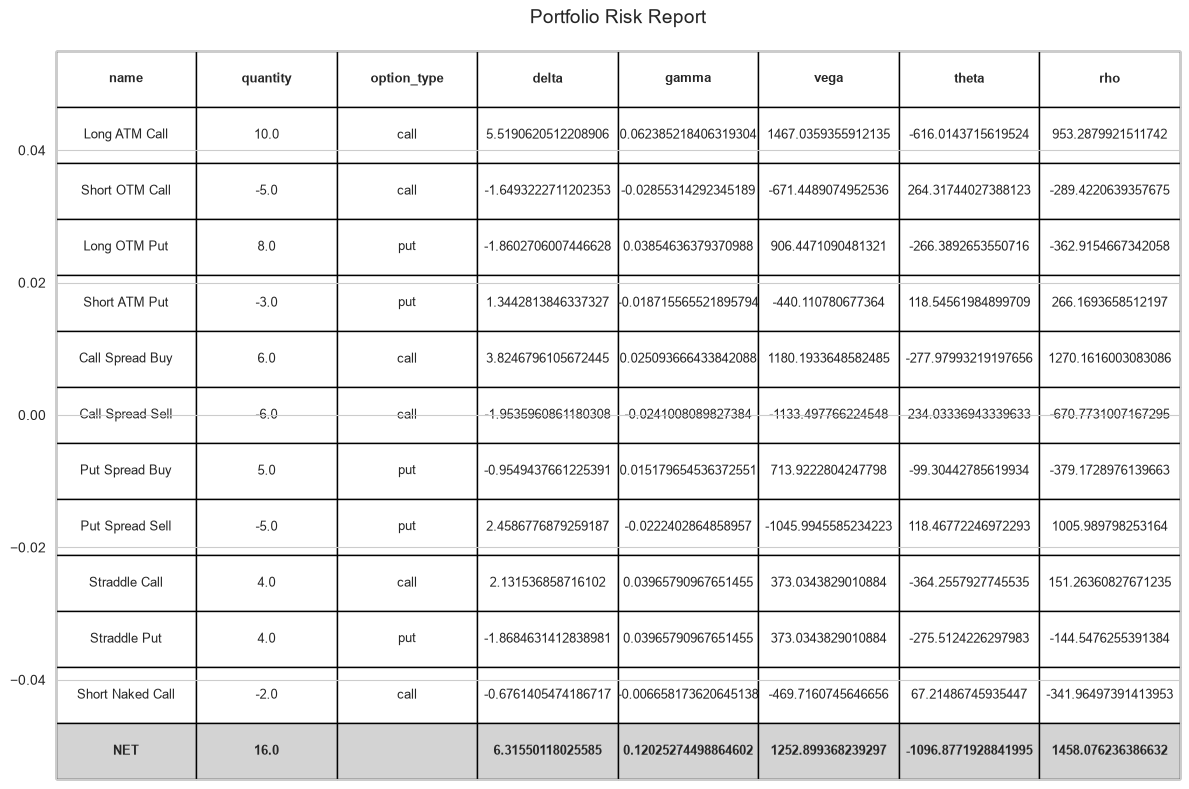

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.axis('tight')
ax.xaxis.set_visible(False)

table = ax.table(
    cellText=risk_report.values,
    colLabels=risk_report.columns,
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)

table.auto_set_font_size(False)
table.set_fontsize(9)

for i in range(len(risk_report.columns)):
    table[(0, i)].set_text_props(weight='bold')

for i in range(len(risk_report)):
    if risk_report.iloc[i]['name'] == 'NET':
        for j in range(len(risk_report.columns)):
            table[(i+1, j)].set_facecolor('lightgray')
            table[(i+1, j)].set_text_props(weight='bold')

plt.title("Portfolio Risk Report", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Stress Test

In [11]:
tester = StressTester(portfolio, S, sigma_hat)
stress_results = tester.historical_scenarios()

print("\nHistorical Stress Test Results:")
print(stress_results.to_string(index=False))


Historical Stress Test Results:
    scenario  spot_move_pct  vol_move_pct  estimated_pnl
 COVID Crash          -0.30           2.0    2000.343920
    2008 GFC          -0.20           1.5     707.640407
 Volmageddon          -0.05           1.0      62.676957
Dot-com Bust          -0.15           0.8     213.006852
Soft Landing           0.20          -0.3    2195.889024


# Table 2

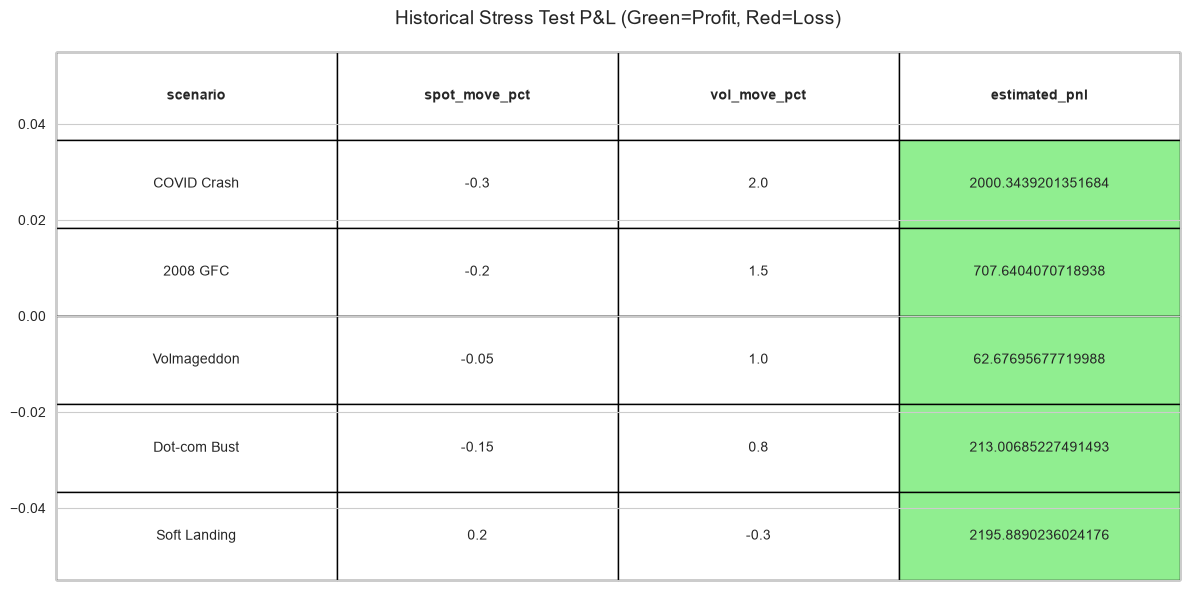

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('tight')
ax.xaxis.set_visible(False)

table = ax.table(
    cellText=stress_results.values,
    colLabels=stress_results.columns,
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)

table.auto_set_font_size(False)
table.set_fontsize(10)

for i in range(len(stress_results.columns)):
    table[(0, i)].set_text_props(weight='bold')

for i in range(len(stress_results)):
    pnl = stress_results.iloc[i]['estimated_pnl']
    for j in range(len(stress_results.columns)):
        if stress_results.columns[j] == 'estimated_pnl':
            if pnl > 0:
                table[(i+1, j)].set_facecolor('lightgreen')
            elif pnl < 0:
                table[(i+1, j)].set_facecolor('lightcoral')

plt.title("Historical Stress Test P&L (Green=Profit, Red=Loss)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Heatmap

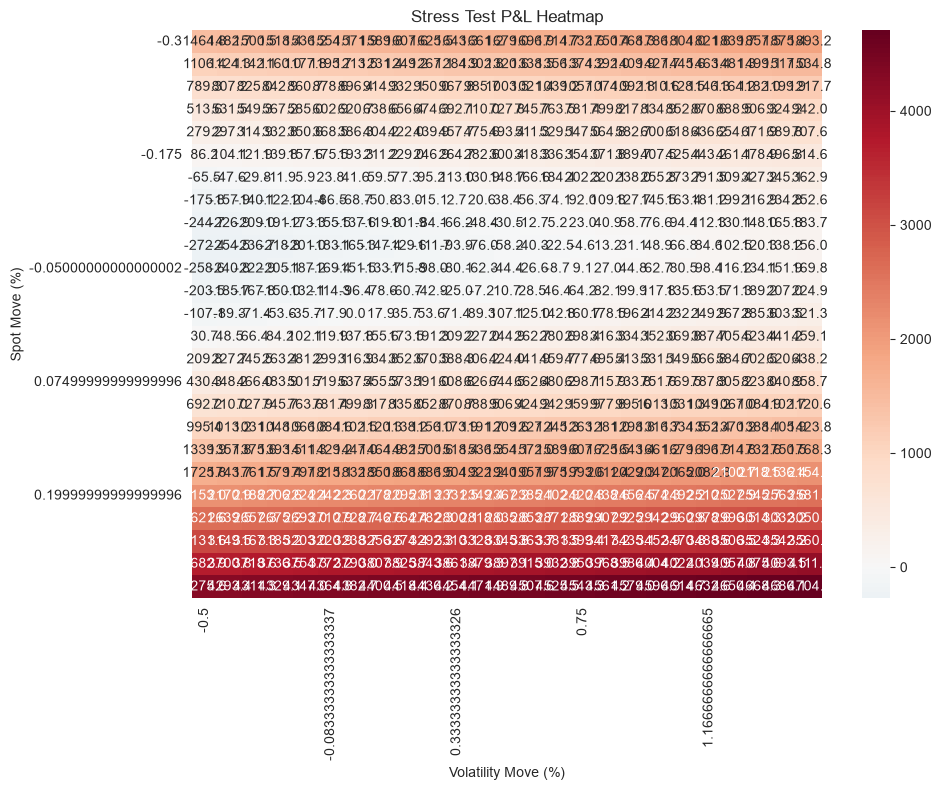

In [14]:
stress_surface = tester.stress_surface()

fig, ax = plt.subplots(figsize=(10, 8))
heatmap_data = stress_surface.pivot(index='spot_move_pct', columns='vol_move_pct', values='pnl')

sns.heatmap(
    heatmap_data,
    cmap='RdBu_r',
    center=0,
    annot=True,
    fmt='.1f',
    ax=ax,
    xticklabels=5,
    yticklabels=5
)

ax.set_xlabel('Volatility Move (%)')
ax.set_ylabel('Spot Move (%)')
ax.set_title('Stress Test P&L Heatmap')
plt.tight_layout()
plt.show()

# Summary

In [15]:
print("\n" + "="*70)
print("KEY TAKEAWAYS — PORTFOLIO-LEVEL RISK")
print("="*70)
print("\n1. Portfolio-Level Greeks Aggregation:")
print("   - Net Greeks = sum of position Greeks × quantity")
print("   - This is the EXACT tool that a Goldman Strats analyst builds in first month")
print("   - Portfolio-level Greeks is core of what risk desks do daily")
print("\n2. Dollar Greeks:")
print("   - Dollar Delta = Delta × S (sensitivity per 1% move)")
print("   - Dollar Vega = Vega × 0.01 (sensitivity per 1 vol point)")
print("   - Used for risk reporting and position limits")
print("\n3. Stress Testing:")
print("   - Scenario P&L = Delta×dS + 0.5×Gamma×dS² + Vega×dVol")
print("   - Historical scenarios: COVID Crash, 2008 GFC, Volmageddon, etc.")
print("   - This is word-for-word the BofA GRA job description")
print("\n4. Why no student project does this:")
print("   - Requires understanding what a book of options looks like, not just single option")
print("   - Shows you understand market-making desk risk management")
print("   - Makes you real-desk-ready, not just textbook-ready")
print("="*70)


KEY TAKEAWAYS — PORTFOLIO-LEVEL RISK

1. Portfolio-Level Greeks Aggregation:
   - Net Greeks = sum of position Greeks × quantity
   - This is the EXACT tool that a Goldman Strats analyst builds in first month
   - Portfolio-level Greeks is core of what risk desks do daily

2. Dollar Greeks:
   - Dollar Delta = Delta × S (sensitivity per 1% move)
   - Dollar Vega = Vega × 0.01 (sensitivity per 1 vol point)
   - Used for risk reporting and position limits

3. Stress Testing:
   - Scenario P&L = Delta×dS + 0.5×Gamma×dS² + Vega×dVol
   - Historical scenarios: COVID Crash, 2008 GFC, Volmageddon, etc.
   - This is word-for-word the BofA GRA job description

4. Why no student project does this:
   - Requires understanding what a book of options looks like, not just single option
   - Shows you understand market-making desk risk management
   - Makes you real-desk-ready, not just textbook-ready
